In [62]:
#imports
import pandas as pd
import matplotlib.pyplot as plt


# Investigate H1B Data for Rare Earth Mineral Keywords

In [63]:
df=pd.read_excel(r"C:\Users\linds\OneDrive\Documents\Unidos\LCA_Disclosure_Data_FY2026_Q1.xlsx")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Software Developers'),
  Text(1, 0, 'Computer Systems Engineers/Architects'),
  Text(2, 0, 'Information Technology Project Managers'),
  Text(3, 0, 'Software Quality Assurance Analysts and Testers'),
  Text(4, 0, 'Data Scientists'),
  Text(5, 0, 'Computer and Information Systems Managers'),
  Text(6, 0, 'Computer Programmers'),
  Text(7, 0, 'Computer Systems Analysts'),
  Text(8, 0, 'Business Intelligence Analysts'),
  Text(9, 0, 'Mechanical Engineers'),
  Text(10, 0, 'Electronics Engineers, Except Computer'),
  Text(11, 0, 'Financial and Investment Analysts'),
  Text(12, 0, 'Database Administrators'),
  Text(13, 0, 'Electrical Engineers'),
  Text(14, 0, 'Medical Scientists, Except Epidemiologists')])

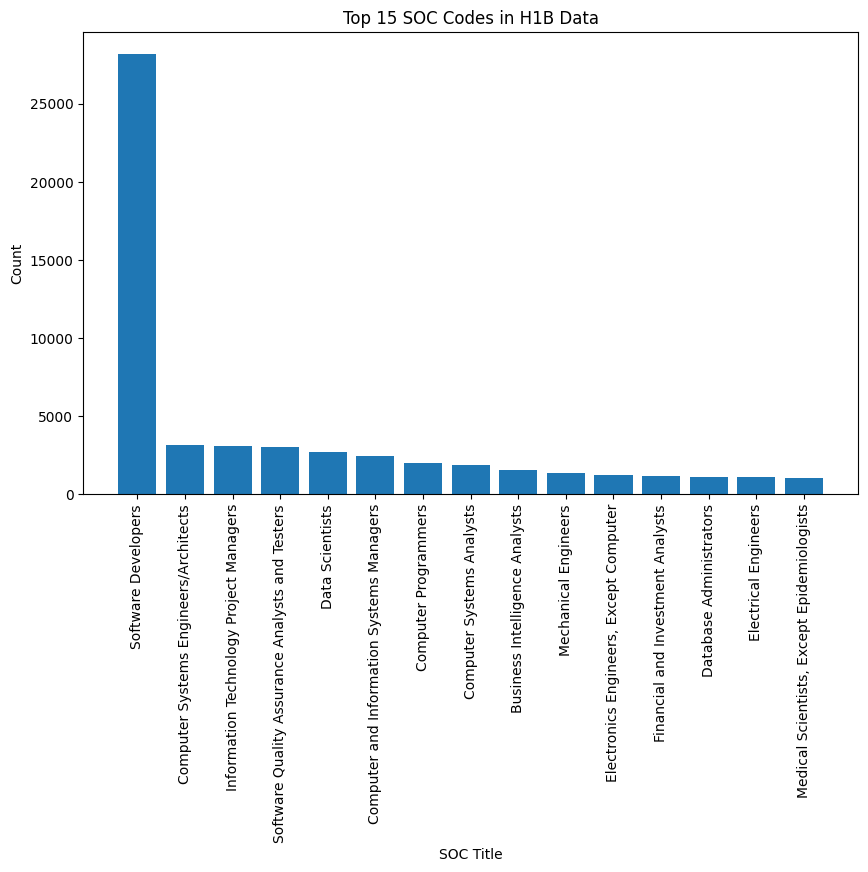

In [64]:
#Histogram of top 20 SOC codes

plt.figure(figsize=(10,6))
plt.bar(df['SOC_TITLE'].value_counts().head(15).index, df['SOC_TITLE'].value_counts().head(15).values)
plt.xlabel('SOC Title')
plt.ylabel('Count')
plt.title('Top 15 SOC Codes in H1B Data')
plt.xticks(rotation=90)

In [65]:
soc_codes = ['17-2151.00', '17-2131.00', '19-2042.00', '19-4042.00', '17-2081.00', '17-3025.00', '11-9041.00', '11-9121.00', '47-1011.00', '47-5022.00', '47-5023.00', '47-5032.00', '47-5043.00', '47-5044.00', '47-5049.00', '47-5081.00', '47-5012.00', '51-9021.00', '51-9012.00', '51-9011.00', '51-4051.00', '51-8099.00']

naics_codes = ['212290', '212230', '331410', '213114', '212390', '212291']

soc_code_related = df[df['SOC_CODE'].isin(soc_codes) & df['NAICS_CODE'].astype(str).isin(naics_codes)]

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Chief Geoscientist'),
  Text(1, 0, 'Senior Geologist'),
  Text(2, 0, 'Metallurgist II'),
  Text(3, 0, 'Manager, Mine Reclamation'),
  Text(4, 0, 'General Manager Sierrita'),
  Text(5, 0, 'Mine Engineering Manager “ North America'),
  Text(6, 0, 'Mine Engineer II')])

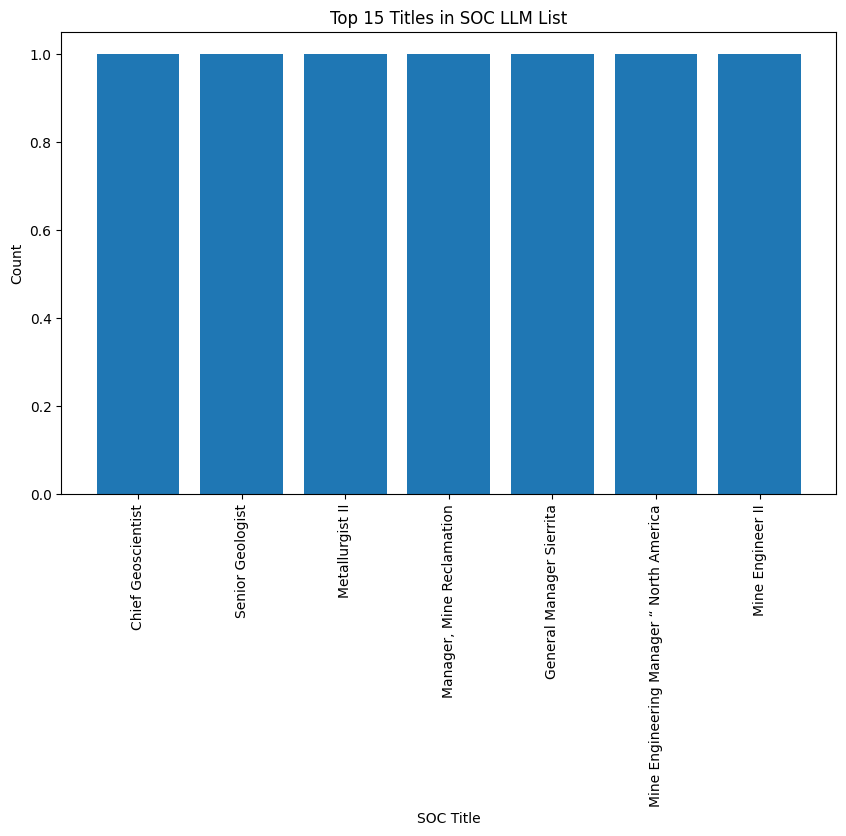

In [66]:
plt.figure(figsize=(10,6))
plt.bar(soc_code_related['JOB_TITLE'].value_counts().head(15).index, soc_code_related['JOB_TITLE'].value_counts().head(15).values)
plt.xlabel('SOC Title')
plt.ylabel('Count')
plt.title('Top 15 Titles in SOC LLM List')
plt.xticks(rotation=90)

In [67]:
import re

# 1. The "Wide Net" Regex Pattern (Includes broad minerals)
pattern = (
    # Group A: Broad Industry Terms & Recycling
    r'(?i)(critical mineral|critical material|strategic mineral|strategic material|'
    r'battery metal|battery material|energy metal|technology metal|battery recycling|black mass|'
    
    # Group B: Processing & Extraction Jargon
    r'extractive|hydrometallurg|pyrometallurg|solvent extraction|beneficiation|'
    r'leaching|bioleaching|separation engineer|separation scientist|metallurgist|'
    r'mineral processing|direct lithium extraction|\bDLE\b|electrowinning|electrorefining|'
    r'froth flotation|ion exchange|comminution|calcination|'
    
    # Group C: Rare Earth minerals
    r'rare earth|lanthanide|neodymium|praseodymium|dysprosium|terbium|scandium|yttrium|'
    r'cerium|lanthanum|samarium|europium|gadolinium|holmium|erbium|thulium|ytterbium|lutetium|'
    r'lithium|cobalt|gallium|germanium|indium|tellurium|tantalum|niobium|'
    r'antimony|bismuth|beryllium|tungsten|vanadium|cesium|rubidium|hafnium|zirconium|'
    r'fluorspar|fluorine|barite|chromium|\btin\b|\barsenic\b|uranium|'
    r'platinum|palladium|iridium|rhodium|ruthenium|silicon carbide| eletrical steel|'
    r'copper|aluminum|zinc|graphite|nickel|manganese|magnesium|titanium|'
    r'electrical steel|phosphorus|'

    # Group D: Ores, Brines, & Key Compounds
    r'spodumene|brine|bastnaesite|monazite|laterite|lithium carbonate|lithium hydroxide|\bNdFeB\b)'
)

# 2. Extract the keywords found into a list so you know WHY a row was flagged
df['critical_mineral_keywords'] = df['JOB_TITLE'].str.findall(pattern).apply(
    lambda matches: [word for tuple_group in matches for word in tuple_group if word]
)

# 3. Create the filter column
df['is_critical_mineral_job'] = df['critical_mineral_keywords'].astype(bool)

# 4. View your results
wide_net_df = df[df['is_critical_mineral_job'] == True]

# Print the top results to verify
print(wide_net_df[['JOB_TITLE', 'critical_mineral_keywords', 'EMPLOYER_NAME']].head(10))

                                               JOB_TITLE  \
22913                                    Metallurgist II   
23942  Strategic Materials & Business Development Ana...   
27650                     Lithium Key Commodity Director   
28800  Postdoc Res Assoc-Platinum Group Metals Recycl...   
43585  Senior Vice President of Critical Minerals Pro...   
56288                                       Metallurgist   
65435                               Process Metallurgist   
69073                       Product Metallurgist “ Sales   
76105  Principal Software Engineer Full Stack - Coppe...   
78949                                 Plant Metallurgist   

                               critical_mineral_keywords  \
22913               [M, e, t, a, l, l, u, r, g, i, s, t]   
23942  [S, t, r, a, t, e, g, i, c,  , M, a, t, e, r, ...   
27650                              [L, i, t, h, i, u, m]   
28800                           [P, l, a, t, i, n, u, m]   
43585   [C, r, i, t, i, c, a, l,  , M, 

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Metallurgist II'),
  Text(1, 0, 'Strategic Materials & Business Development Analyst'),
  Text(2, 0, 'Lithium Key Commodity Director'),
  Text(3, 0, 'Postdoc Res Assoc-Platinum Group Metals Recycling Specialist'),
  Text(4, 0, 'Senior Vice President of Critical Minerals Processing'),
  Text(5, 0, 'Metallurgist'),
  Text(6, 0, 'Process Metallurgist'),
  Text(7, 0, 'Product Metallurgist “ Sales'),
  Text(8, 0, 'Principal Software Engineer Full Stack - Copper/DSL'),
  Text(9, 0, 'Plant Metallurgist')])

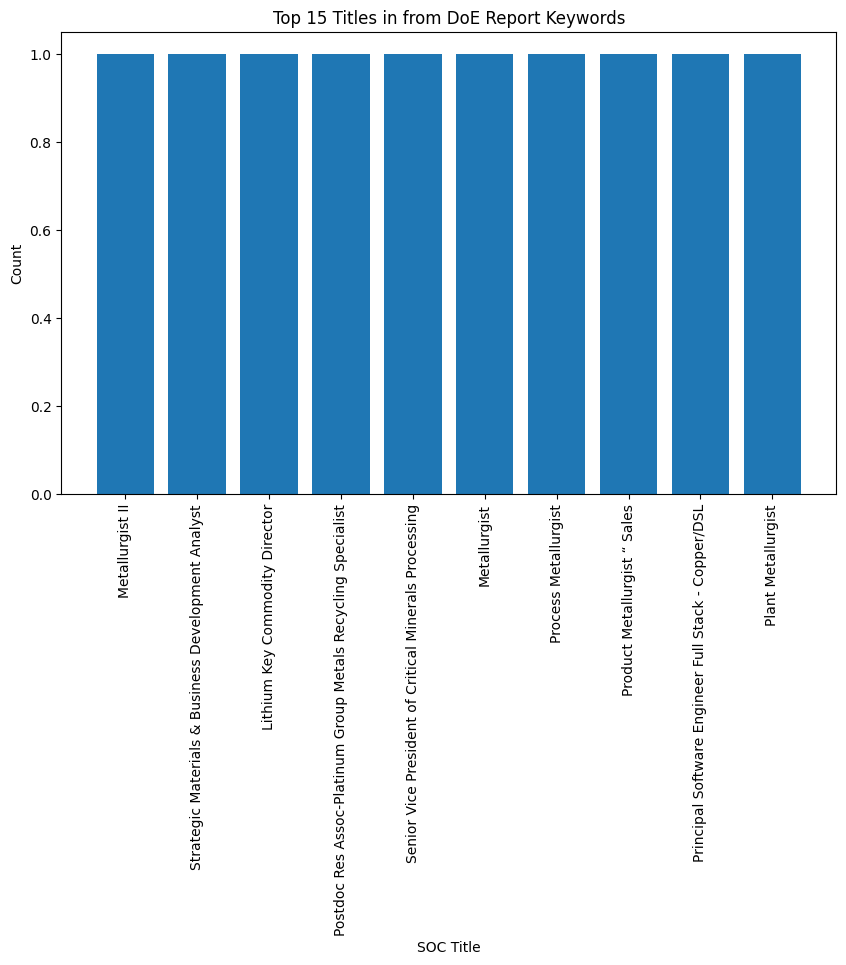

In [68]:
plt.figure(figsize=(10,6))
plt.bar(wide_net_df['JOB_TITLE'].value_counts().head(15).index, wide_net_df['JOB_TITLE'].value_counts().head(15).values)
plt.xlabel('SOC Title')
plt.ylabel('Count')
plt.title('Top 15 Titles in from DoE Report Keywords')
plt.xticks(rotation=90)